# 010 — Exploratory Data Analysis

Inventory the dataset, validate artwork-grouped splits, visualise sample pairs and pixel distributions.

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on sys.path
project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import (
    extract_artwork_id,
    grouped_train_val_test_split,
    load_image_pairs,
)
from scripts.visualization import plot_sample_pairs

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset inventory

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
print(f"Total pairs: {len(pairs)}")
print(f"\nFirst 5 pairs:")
for rgb, ir in pairs[:5]:
    print(f"  RGB: {rgb.name}  |  IR: {ir.name}")

Total pairs: 648

First 5 pairs:
  RGB: a1_sezione_0.jpg  |  IR: a1_sezione_0.jpg
  RGB: a1_sezione_1.jpg  |  IR: a1_sezione_1.jpg
  RGB: a1_sezione_10.jpg  |  IR: a1_sezione_10.jpg
  RGB: a1_sezione_11.jpg  |  IR: a1_sezione_11.jpg
  RGB: a1_sezione_12.jpg  |  IR: a1_sezione_12.jpg


In [4]:
artwork_ids = [extract_artwork_id(p[0].stem) for p in pairs]
counts = Counter(artwork_ids)

print(f"Unique artworks: {len(counts)}\n")
print(f"{'Artwork':<20} {'Sections':>8}")
print("-" * 30)
for artwork, n in sorted(counts.items()):
    print(f"{artwork:<20} {n:>8}")
print("-" * 30)
print(f"{'Total':<20} {sum(counts.values()):>8}")

Unique artworks: 24

Artwork              Sections
------------------------------
a1                         20
a2                         20
b1                         24
c1                         20
corpo                      15
cristo                     20
mano                       24
natmorta1                  35
natmorta2                  35
natmorta3                  35
oblato_tot                 35
oblato_volto               42
orecchio                   24
q1                         24
q2                         20
q3                         24
santo                      30
sch01                      25
sch02                      30
sch03                      30
testa                      24
torso                      36
veste                      36
volto                      20
------------------------------
Total                     648


## 2. Train / val / test split by artwork

In [5]:
train_pairs, val_pairs, test_pairs = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

train_artworks = sorted({extract_artwork_id(p[0].stem) for p in train_pairs})
val_artworks   = sorted({extract_artwork_id(p[0].stem) for p in val_pairs})
test_artworks  = sorted({extract_artwork_id(p[0].stem) for p in test_pairs})

print(f"Train: {len(train_pairs):>4} patches | {len(train_artworks):>2} artworks: {train_artworks}")
print(f"Val:   {len(val_pairs):>4} patches | {len(val_artworks):>2} artworks: {val_artworks}")
print(f"Test:  {len(test_pairs):>4} patches | {len(test_artworks):>2} artworks: {test_artworks}")

Train:  423 patches | 16 artworks: ['c1', 'corpo', 'cristo', 'mano', 'natmorta1', 'natmorta3', 'oblato_tot', 'oblato_volto', 'orecchio', 'q1', 'q2', 'q3', 'sch01', 'testa', 'veste', 'volto']
Val:    110 patches |  4 artworks: ['a2', 'b1', 'sch03', 'torso']
Test:   115 patches |  4 artworks: ['a1', 'natmorta2', 'santo', 'sch02']


In [6]:
# Verify no artwork appears in more than one fold
assert not (set(train_artworks) & set(val_artworks)),  "Leakage: train ∩ val"
assert not (set(train_artworks) & set(test_artworks)), "Leakage: train ∩ test"
assert not (set(val_artworks)   & set(test_artworks)), "Leakage: val ∩ test"
assert len(train_pairs) + len(val_pairs) + len(test_pairs) == len(pairs), "Total mismatch"
print("All split integrity checks passed.")

All split integrity checks passed.


## 3. Sample RGB / IR pair visualisation

In [ ]:
random.seed(settings.SEED)
sample = random.sample(pairs, min(5, len(pairs)))

rgb_imgs = [np.array(Image.open(p[0]).convert("RGB")) / 255.0 for p in sample]
ir_imgs  = [np.array(Image.open(p[1]).convert("L"))  / 255.0 for p in sample]

fig = plot_sample_pairs(rgb_imgs, ir_imgs, n=5)
plt.show()

## 4. Pixel intensity distributions

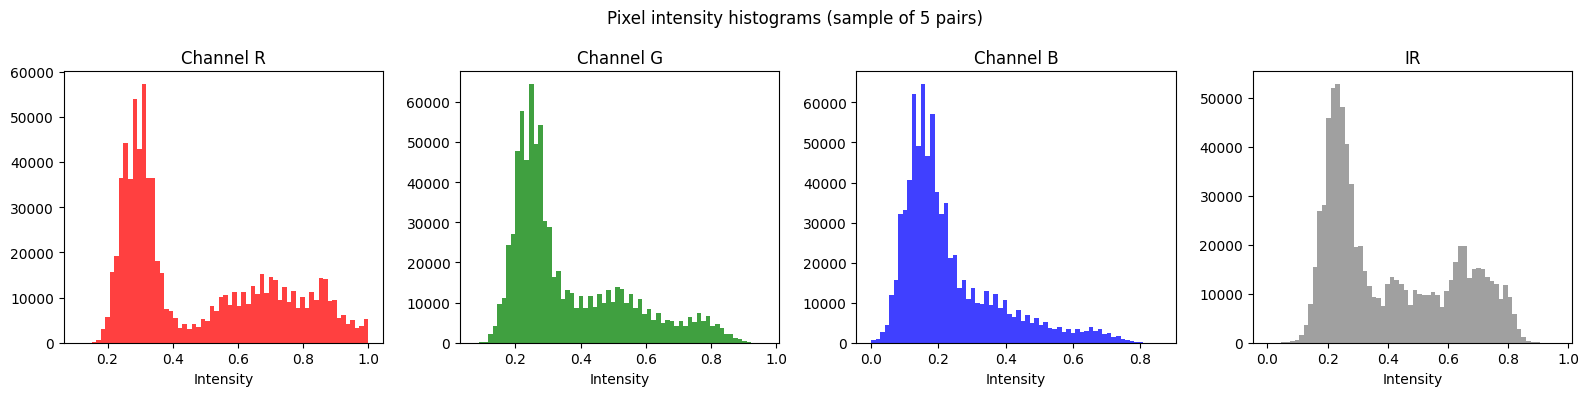

In [8]:
rgb_arr = np.stack(rgb_imgs)   # (N, H, W, 3)
ir_arr  = np.stack(ir_imgs)    # (N, H, W)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Pixel intensity histograms (sample of 5 pairs)")

for i, (ch, col) in enumerate(zip(["R", "G", "B"], ["red", "green", "blue"])):
    axes[i].hist(rgb_arr[..., i].ravel(), bins=64, color=col, alpha=0.75)
    axes[i].set_title(f"Channel {ch}")
    axes[i].set_xlabel("Intensity")

axes[3].hist(ir_arr.ravel(), bins=64, color="gray", alpha=0.75)
axes[3].set_title("IR")
axes[3].set_xlabel("Intensity")

plt.tight_layout()
plt.show()

## 5. Image dimensions check

In [9]:
sizes = {}
for rgb_path, ir_path in pairs[:20]:
    rgb_size = Image.open(rgb_path).size  # (W, H)
    ir_size  = Image.open(ir_path).size
    sizes[rgb_size] = sizes.get(rgb_size, 0) + 1
    assert rgb_size == ir_size, f"Size mismatch: {rgb_path.name}"

print("Unique image sizes (W×H) in first 20 pairs:")
for size, count in sorted(sizes.items()):
    print(f"  {size[0]}×{size[1]}: {count} images")
print(f"\nPATCH_MULTIPLE = {settings.PATCH_MULTIPLE}")
print(f"400 mod {settings.PATCH_MULTIPLE} = {400 % settings.PATCH_MULTIPLE} (0 = no padding needed at training time)")

Unique image sizes (W×H) in first 20 pairs:
  400×400: 20 images

PATCH_MULTIPLE = 16
400 mod 16 = 0 (0 = no padding needed at training time)
